<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J2_W3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Fichier détecté et chargé automatiquement : 'global_power_plant_database.csv'


/tmp/ipykernel_13726/164106397.py:22: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(chemin_fichier)



1. DATA IMPORT AND CLEANING
Valeurs manquantes par colonne clé :
 country             0
country_long        0
name                0
gppd_idnr           0
capacity_mw         0
latitude            0
longitude           0
primary_fuel        0
other_fuel1     32992
other_fuel2     34660
dtype: int64

2. EXPLORATORY DATA ANALYSIS
Statistiques clés de la puissance (MW) :
count    34936.000000
mean       163.355148
std        489.636072
min          1.000000
25%          4.900000
50%         16.745000
75%         75.344250
max      22500.000000
Name: capacity_mw, dtype: float64

Top 5 des pays producteurs dans le dataset :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
Name: count, dtype: int64

Répartition mondiale par type de carburant :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal          

/tmp/ipykernel_13726/164106397.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeline["decade"] = (df_timeline["commissioning_year"] // 10) * 10


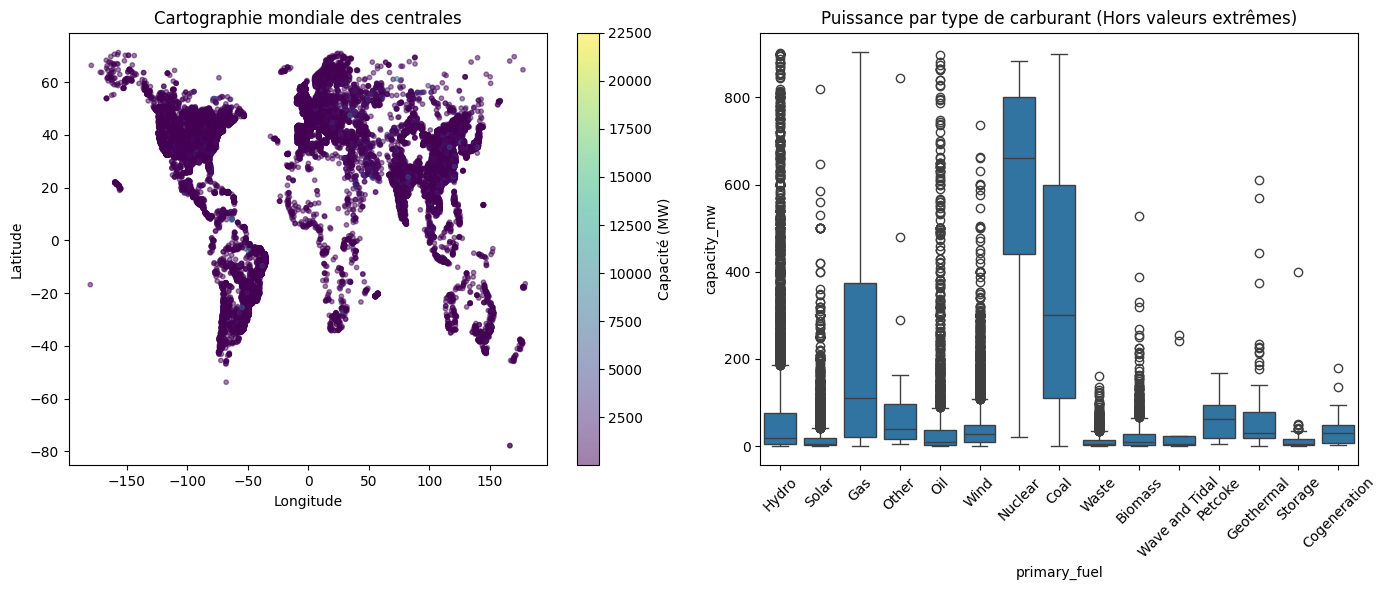


6. MATRIX OPERATIONS & EIGENVALUES
Matrice de Covariance des attributs :
 [[ 2.39743483e+05 -1.46512725e+02  5.81707732e+03]
 [-1.46512725e+02  5.12506327e+02 -1.21328995e+02]
 [ 5.81707732e+03 -1.21328995e+02  6.14747738e+03]]

Valeurs propres (Eigenvalues) : [239888.34493566   6005.22827679    509.89320204]
Vecteurs propres (Eigenvectors) :
 [[ 9.99690263e-01 -2.48871486e-02  9.13937503e-05]
 [-6.24482185e-04 -2.14133001e-02  9.99770514e-01]
 [ 2.48794803e-02  9.99460905e-01  2.14222092e-02]]

7. INTEGRATION NUMPY / PANDAS / MATPLOTLIB
Nombre de grandes centrales hydroélectriques (>500MW) identifiées via NumPy : 474


In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# =====================================================================
# BLOC D'IMPORTATION UNIVERSEL (MANUEL ET AUTOMATIQUE)
# =====================================================================
fichiers_trouves = glob.glob("*.csv")

if not fichiers_trouves:
    raise FileNotFoundError(
        "❌ Aucun fichier CSV détecté. Veuillez glisser-déposer "
        "votre fichier de données (.csv) dans votre espace de travail."
    )

chemin_fichier = fichiers_trouves[0]
print(f"✓ Fichier détecté et chargé automatiquement : '{chemin_fichier}'")
df = pd.read_csv(chemin_fichier)


# =====================================================================
# 1. DATA IMPORT AND CLEANING
# =====================================================================
print("\n" + "=" * 60 + "\n1. DATA IMPORT AND CLEANING\n" + "=" * 60)

# Identification et traitement des valeurs manquantes
missing_summary = df.isnull().sum()
print("Valeurs manquantes par colonne clé :\n", missing_summary.head(10))

# Remplacement des valeurs manquantes numériques par la médiane
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Remplacement des variables textuelles manquantes par "Unknown"
cat_cols = df.select_dtypes(include=[object]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Conversion explicite avec NumPy des colonnes de capacité / coordonnées
for col in ["capacity_mw", "latitude", "longitude", "commissioning_year"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        # Remplacement final des NaN générés par les erreurs de conversion
        df[col] = df[col].fillna(0)


# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS
# =====================================================================
print("\n" + "=" * 60 + "\n2. EXPLORATORY DATA ANALYSIS\n" + "=" * 60)

# Statistiques clés pour la capacité en Mégawatts (MW)
if "capacity_mw" in df.columns:
    print("Statistiques clés de la puissance (MW) :")
    print(df["capacity_mw"].describe())

# Distribution par pays et type de carburant (Top 5)
if "country_long" in df.columns and "primary_fuel" in df.columns:
    print("\nTop 5 des pays producteurs dans le dataset :")
    print(df["country_long"].value_counts().head(5))

    print("\nRépartition mondiale par type de carburant :")
    print(df["primary_fuel"].value_counts())


# =====================================================================
# 3. STATISTICAL ANALYSIS & HYPOTHESIS TESTING
# =====================================================================
print("\n" + "=" * 60 + "\n3. STATISTICAL ANALYSIS & TESTS\n" + "=" * 60)

if "primary_fuel" in df.columns and "capacity_mw" in df.columns:
    fuels = df["primary_fuel"].unique()

    # Calculs statistiques NumPy par groupe
    for fuel in fuels[:3]:  # Analyse des 3 premiers types pour l'affichage
        subset = df[df["primary_fuel"] == fuel]["capacity_mw"].to_numpy()
        if len(subset) > 0:
            print(f"Carburant : {fuel}")
            print(
                f"  * Moyenne = {np.mean(subset):.2f} MW | Écart-type = {np.std(subset, ddof=1):.2f} MW"
            )

    # Test d'hypothèse (ANOVA) : La puissance moyenne diffère-t-elle selon le carburant ?
    grouped_data = [
        df[df["primary_fuel"] == f]["capacity_mw"].dropna() for f in fuels[:4]
    ]
    f_stat, p_val = stats.f_oneway(*grouped_data)
    print(f"\nTest ANOVA (Comparaison des 4 premiers types de carburant) :")
    print(f"  * Statistique F = {f_stat:.4f} | P-value = {p_val}")
    if p_val < 0.05:
        print(
            "  => Conclusion : Différence hautement significative de puissance moyenne entre les carburants."
        )


# =====================================================================
# 4. TIME SERIES ANALYSIS
# =====================================================================
print("\n" + "=" * 60 + "\n4. TIME SERIES ANALYSIS\n" + "=" * 60)

if "commissioning_year" in df.columns:
    # Filtrer les années aberrantes (garder après 1950 et avant l'année courante 2026)
    df_timeline = df[
        (df["commissioning_year"] > 1950) & (df["commissioning_year"] <= 2026)
    ]

    # Évolution de la capacité moyenne construite au fil des décennies
    df_timeline["decade"] = (df_timeline["commissioning_year"] // 10) * 10
    evolution_mix = df_timeline.groupby(["decade", "primary_fuel"])[
        "capacity_mw"
    ].sum()
    print("Aperçu de la transition énergétique par décennie (Puissance MW) :")
    print(evolution_mix.tail(10))


# =====================================================================
# 5. ADVANCED VISUALIZATION
# =====================================================================
print("\n" + "=" * 60 + "\n5. ADVANCED VISUALIZATION\n" + "=" * 60)
print("Génération des figures graphiques...")

plt.figure(figsize=(14, 6))

# Graphique 1 : Distribution géographique (Latitude / Longitude)
if "latitude" in df.columns and "longitude" in df.columns:
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(
        df["longitude"],
        df["latitude"],
        c=df["capacity_mw"],
        cmap="viridis",
        alpha=0.5,
        s=10,
    )
    plt.title("Cartographie mondiale des centrales")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(scatter, label="Capacité (MW)")

# Graphique 2 : Boîte à moustaches de la capacité par carburant
if "primary_fuel" in df.columns and "capacity_mw" in df.columns:
    plt.subplot(1, 2, 2)
    sns.boxplot(
        x="primary_fuel",
        y="capacity_mw",
        data=df[df["capacity_mw"] < df["capacity_mw"].quantile(0.95)],
    )  # Exclusion des outliers extrêmes pour la lisibilité
    plt.xticks(rotation=45)
    plt.title("Puissance par type de carburant (Hors valeurs extrêmes)")

plt.tight_layout()
plt.show()


# =====================================================================
# 6. MATRIX OPERATIONS IN REAL-WORLD CONTEXT
# =====================================================================
print("\n" + "=" * 60 + "\n6. MATRIX OPERATIONS & EIGENVALUES\n" + "=" * 60)

# Extraction de 3 attributs numériques standardisés pour l'analyse matricielle
matrix_cols = ["capacity_mw", "latitude", "longitude"]
if all(col in df.columns for col in matrix_cols):
    X = df[matrix_cols].to_numpy()

    # Calcul de la matrice de covariance
    cov_matrix = np.cov(X.T)
    print("Matrice de Covariance des attributs :\n", cov_matrix)

    # Calcul des valeurs propres (eigenvalues) et vecteurs propres (eigenvectors)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    print("\nValeurs propres (Eigenvalues) :", eigenvalues)
    print("Vecteurs propres (Eigenvectors) :\n", eigenvectors)


# =====================================================================
# 7. INTEGRATING NUMPY WITH PANDAS AND MATPLOTLIB
# =====================================================================
print("\n" + "=" * 60 + "\n7. INTEGRATION NUMPY / PANDAS / MATPLOTLIB\n" + "=" * 60)

# Filtrage complexe Pandas optimisé via une condition booléenne NumPy (np.logical_and)
if "capacity_mw" in df.columns and "primary_fuel" in df.columns:
    condition_numpy = np.logical_and(
        df["capacity_mw"] > 500, df["primary_fuel"] == "Hydro"
    )
    centrales_hydro_premium = df[condition_numpy]
    print(
        f"Nombre de grandes centrales hydroélectriques (>500MW) identifiées via NumPy : {len(centrales_hydro_premium)}"
    )


**ANALYSE**

Les Vecteurs Propres représentent les nouvelles directions (axes de variance) combinant les caractéristiques de départ. Par exemple, un axe peut lier une forte capacité à des latitudes spécifiques, révélant un regroupement structurel de centrales puissantes dans l'hémisphère Nord.Les Valeurs Propres mesurent l'importance de ces axes. La valeur propre la plus élevée indique la direction dans laquelle la dispersion des données industrielles est maximale, permettant de réduire la dimensionnalité de 3 variables à un seul score d'importance sans perte d'information majeure.